# Moving application of ShellSIM from 1D time series data to complex 4D gridded dataset

Needed Variables 

T_timeseries=  Temperature Time series  
S_timeseries=  Practical Salinity Time series  
Chl_timeseries= Chlorophyll Time series  
POC_timeseries= Particulate Organic Carbon Time series  
POM_timeseries=  Particulate Organic Matter Time series  
TPM_timeseries= Total Particulate Matter   Time series  

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import pyfabm
import os
from dask.diagnostics import ProgressBar
import warnings
import gc
import datetime
from contextlib import redirect_stdout # For redirecting stdout
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Define the integration time period 
start = '01-06-2021'
end = '12-06-2021'
time_horizon = pd.date_range(start=start, end=end, freq='1d')
time_horizon_len = len(time_horizon)
time_horizon_len

335

In [3]:
#  Lat lon chunking method
chunking_config={'time': -1, 'latitude': 80, 'longitude': 110}
# Earth's radius in kilometers (used for converting degrees to distance)
# The mean radius is a good approximation for surface area calculation.
EARTH_RADIUS_KM = 6371.0 # km
_GLOBAL_COORDS = None


def load_nc_file(file_path, var_name_in_file, chunking_config=None):
    """
    Loads a NetCDF file or creates a fake one if not found.
    """
    global _GLOBAL_COORDS
    fake_filename = f'{var_name_in_file}_gridded_FAKE.nc'
    
    if os.path.exists(file_path):
        print(f"Successfully loaded: {var_name_in_file}")
        # Load the dataset
        ds = xr.open_dataset(file_path, chunks=chunking_config)
        # --- START COORDINATE & AREA CALCULATION BLOCK ---
        try:
            # 1. Get Lat/Lon coordinates safely
            lat_coords = ds['latitude'].values if 'latitude' in ds.coords else ds['lat'].values
            lon_coords = ds['longitude'].values if 'longitude' in ds.coords else ds['lon'].values
    
            # Get time coordinate if it exists
            time_coords = ds['time'].values if 'time' in ds.coords else None
            
            # Store global coordinates from the FIRST real dataset loaded
            if _GLOBAL_COORDS is None:
                _GLOBAL_COORDS = {
                    'lat': lat_coords,
                    'lon': lon_coords,
                    'time': time_coords,  
                    'lat_name': 'latitude' if 'latitude' in ds.coords else 'lat',
                    'lon_name': 'longitude' if 'longitude' in ds.coords else 'lon'
                }
                print(f"✅ Set global coordinate reference from: {var_name_in_file}")
            
        except KeyError:
            print("❌ ERROR: The dataset is missing coordinate variables. Expected ('latitude' or 'lat') and ('longitude' or 'lon').")
            return ds

        # Calculate bounds and ranges
        lat_min, lat_max = lat_coords.min(), lat_coords.max()
        lon_min, lon_max = lon_coords.min(), lon_coords.max()

        lat_range_deg = lat_max - lat_min
        lon_range_deg = lon_max - lon_min
        
        # 2. Convert ranges to distance
        lat_distance_km = lat_range_deg * (2 * np.pi * EARTH_RADIUS_KM / 360)
        
        mid_lat_rad = np.deg2rad((lat_max + lat_min) / 2)
        lon_distance_km = lon_range_deg * (2 * np.pi * EARTH_RADIUS_KM / 360) * np.cos(mid_lat_rad)
        
        # 3. Calculate Approximate Area
        approx_area_sq_km = lat_distance_km * lon_distance_km
        
        print(f"🗺️ Geographic Coverage:")
        print(f"  BBOX (xMin, yMin, xMax, yMax)")
        print(f"  BBOX ({lon_min:.2f}, {lat_min:.2f}, {lon_max:.2f}, {lat_max:.2f})")
        print(f"  Lat Range: {lat_min:.2f}° to {lat_max:.2f}° ({lat_range_deg:.2f}°)")
        print(f"  Lon Range: {lon_min:.2f}° to {lon_max:.2f}° ({lon_range_deg:.2f}°)")
        print(f"  Approximate Area: {approx_area_sq_km:,.0f} km²")
        print("---------------------------------------------------\n")
        
        return ds
    
    if os.path.exists(fake_filename):
        print(f"Using existing fake dataset: {fake_filename}\n")
        return xr.open_dataset(fake_filename, chunks=chunking_config)

    # Check if we have global coordinates from a real dataset
    if _GLOBAL_COORDS is None:
        print("⚠️ WARNING: No real dataset loaded yet. Creating fake data with default coordinates.")
        # Default fallback coordinates (your original values)
        fake_lats = np.linspace(40, 50, 100)
        fake_lons = np.linspace(-10, 0, 100)
        time_horizon = np.arange(0, 30)  # Default 30 time steps
        lat_name = 'latitude'
        lon_name = 'longitude'
    else:
        print(f"📍 Creating fake data matching global coordinate reference")
        fake_lats = _GLOBAL_COORDS['lat']
        fake_lons = _GLOBAL_COORDS['lon']
        lat_name = _GLOBAL_COORDS['lat_name']
        lon_name = _GLOBAL_COORDS['lon_name']
        
        # Use time from real dataset if available, otherwise default
        if _GLOBAL_COORDS.get('time') is not None:  # ← CHANGED to .get()
            time_horizon = _GLOBAL_COORDS['time']
        else:
            time_horizon = np.arange(0, 30)
    
    time_horizon_len = len(time_horizon)
    
    # Create fake data with matching dimensions
    fake_data = np.random.rand(time_horizon_len, len(fake_lats), len(fake_lons))
    
    fake_gridded_dataset = xr.Dataset(
        {var_name_in_file: (['time', lat_name, lon_name], fake_data)},
        coords={'time': time_horizon, lat_name: fake_lats, lon_name: fake_lons}
    )
    
    fake_gridded_dataset.to_netcdf(fake_filename)
    print(f"✅ Saved fake dataset to: {fake_filename}")
    print(f"   Coordinates: time[{time_horizon_len}], {lat_name}[{len(fake_lats)}], {lon_name}[{len(fake_lons)}]")
    print(f"   BBOX ({fake_lons.min():.2f}, {fake_lats.min():.2f}, {fake_lons.max():.2f}, {fake_lats.max():.2f})\n")
    
    return xr.open_dataset(fake_filename, chunks=chunking_config)

    

In [4]:
# Define datasets to be read and used for model
poc_file_path="/home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_BIO_BGC_3D_REP_015_010/cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_poc_13.00W-42.00E_30.00N-70.00N_0.00-1000.00m_2021-06-01-2021-06-30_3f1f32d8adbe3d686e11d7d4a40be7bb.nc"
poc_var_name = 'poc'  # variable name inside poc.nc

salinity_file_path="/home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_PHY_S_SURFACE_MYNRT_015_013/cmems_obs-mob_glo_phy-sss_my_multi_P1D_sos-sos_error_13.00W-42.00E_30.00N-70.00N_2021-06-01-2021-06-30_9fe69177ea51eb9c1d733df494870646.nc"
salinity_var_name = 'sos' # variable name inside salinity.nc

# Fake data generation to be triggered in the 'except' block of load_nc_file if path doesn't exist
temp_file_path = 'non_existent_temp.nc'
temp_var_name = 'temperature' # variable name inside temperature.nc

chl_file_path = 'non_existent_chl.nc'
chl_var_name = 'chl'

pom_file_path = 'non_existent_pom.nc'
pom_var_name = 'pom'

tpm_file_path = 'non_existent_tpm.nc'
tpm_var_name = 'tpm'


In [5]:
# Load all datasets
print("Loading datasets...\n")
# view bbox with http://bboxfinder.com/#30.060000,-12.940000,69.940000,41.940000
ds_poc = load_nc_file(poc_file_path, poc_var_name)
ds_sal = load_nc_file(salinity_file_path, salinity_var_name)
ds_temp = load_nc_file(temp_file_path, temp_var_name)
ds_chl = load_nc_file(chl_file_path, chl_var_name)
ds_pom = load_nc_file(pom_file_path, pom_var_name)
ds_tpm = load_nc_file(tpm_file_path, tpm_var_name)

Loading datasets...

Successfully loaded: poc


getfattr: /home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_BIO_BGC_3D_REP_015_010/cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_poc_13.00W-42.00E_30.00N-70.00N_0.00-1000.00m_2021-06-01-2021-06-30_3f1f32d8adbe3d686e11d7d4a40be7bb.nc: Operation not supported


✅ Set global coordinate reference from: poc
🗺️ Geographic Coverage:
  BBOX (xMin, yMin, xMax, yMax)
  BBOX (-12.88, 30.12, 41.88, 69.88)
  Lat Range: 30.12° to 69.88° (39.75°)
  Lon Range: -12.88° to 41.88° (54.75°)
  Approximate Area: 17,296,519 km²
---------------------------------------------------

Successfully loaded: sos
🗺️ Geographic Coverage:
  BBOX (xMin, yMin, xMax, yMax)
  BBOX (-12.94, 30.06, 41.94, 69.94)
  Lat Range: 30.06° to 69.94° (39.88°)
  Lon Range: -12.94° to 41.94° (54.88°)
  Approximate Area: 17,390,524 km²
---------------------------------------------------

Using existing fake dataset: temperature_gridded_FAKE.nc



getfattr: /home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_PHY_S_SURFACE_MYNRT_015_013/cmems_obs-mob_glo_phy-sss_my_multi_P1D_sos-sos_error_13.00W-42.00E_30.00N-70.00N_2021-06-01-2021-06-30_9fe69177ea51eb9c1d733df494870646.nc: Operation not supported


Using existing fake dataset: chl_gridded_FAKE.nc

Using existing fake dataset: pom_gridded_FAKE.nc

Using existing fake dataset: tpm_gridded_FAKE.nc



In [6]:
# Align coordinates - using POC data as reference
# Grid alignment using ds_poc as the reference grid and interpolating all other variables to it, 
# as a way to handle mismatched grids.
print("Aligning coordinates...")
ref_lats = ds_poc.latitude
ref_lons = ds_poc.longitude


Aligning coordinates...


In [7]:
interp_kwargs = {'fill_value': 'extrapolate'}

# For 4D variables: Select first depth values -  Select a single depth level and interpolate 
# use .sel(depth=0, method='nearest') to grab the surface layer
poc_daily = ds_poc[poc_var_name].sel(depth=0, method='nearest').interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
sal_daily = ds_sal[salinity_var_name].sel(depth=0, method='nearest').interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)


# Process 3D variables (datasets with no depth)
temp_daily = ds_temp[temp_var_name].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
chl_daily = ds_chl[chl_var_name].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
pom_daily = ds_pom[pom_var_name].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
tpm_daily = ds_tpm[tpm_var_name].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)


# Merge into a single dataset
ds_daily = xr.Dataset({
    'salinity': sal_daily,
    'POC': poc_daily,
    'temperature': temp_daily,
    'Chl': chl_daily,
    'POM': pom_daily,
    'TPM': tpm_daily
})

print("Merged daily dataset")
ds_daily


Merged daily dataset


<xarray.Dataset> Size: 566MB
Dimensions:      (time: 335, latitude: 160, longitude: 220)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2021-01-06 2021-01-07 ... 2021-12-06
  * latitude     (latitude) float32 640B 30.12 30.38 30.62 ... 69.38 69.62 69.88
  * longitude    (longitude) float32 880B -12.88 -12.62 -12.38 ... 41.62 41.88
    depth        float32 4B 0.0
Data variables:
    salinity     (time, latitude, longitude) float64 94MB 40.02 38.56 ... 52.49
    POC          (time, latitude, longitude) float64 94MB nan nan ... nan nan
    temperature  (time, latitude, longitude) float64 94MB -0.6838 ... -3.577
    Chl          (time, latitude, longitude) float64 94MB -4.181 15.9 ... -1.844
    POM          (time, latitude, longitude) float64 94MB -11.42 ... 8.094
    TPM          (time, latitude, longitude) float64 94MB 20.77 ... -10.06

In [9]:
def subset_ds(ds: xr.Dataset, bbox: tuple) -> xr.Dataset:
    """
    Subsets an xarray.Dataset to a given geographic bounding box.
    The function assumes the dataset has 'latitude' and 'longitude'
    coordinates.
    Args:
        ds (xr.Dataset): The dataset to subset.
        bbox (tuple): A tuple containing the bounding box in the
                      format (min_lon, min_lat, max_lon, max_lat).
    Returns:
        xr.Dataset: The spatially subsetted dataset.
    """
    # Unpack the bounding box
    min_lon, min_lat, max_lon, max_lat = bbox

    # Use the .sel() method with slice() to select the data
    # within the bounding box. This is the standard xarray way
    # to select a range of coordinate values.
    subset = ds.sel(
        latitude=slice(min_lat, max_lat),
        longitude=slice(min_lon, max_lon)
    )

    return subset

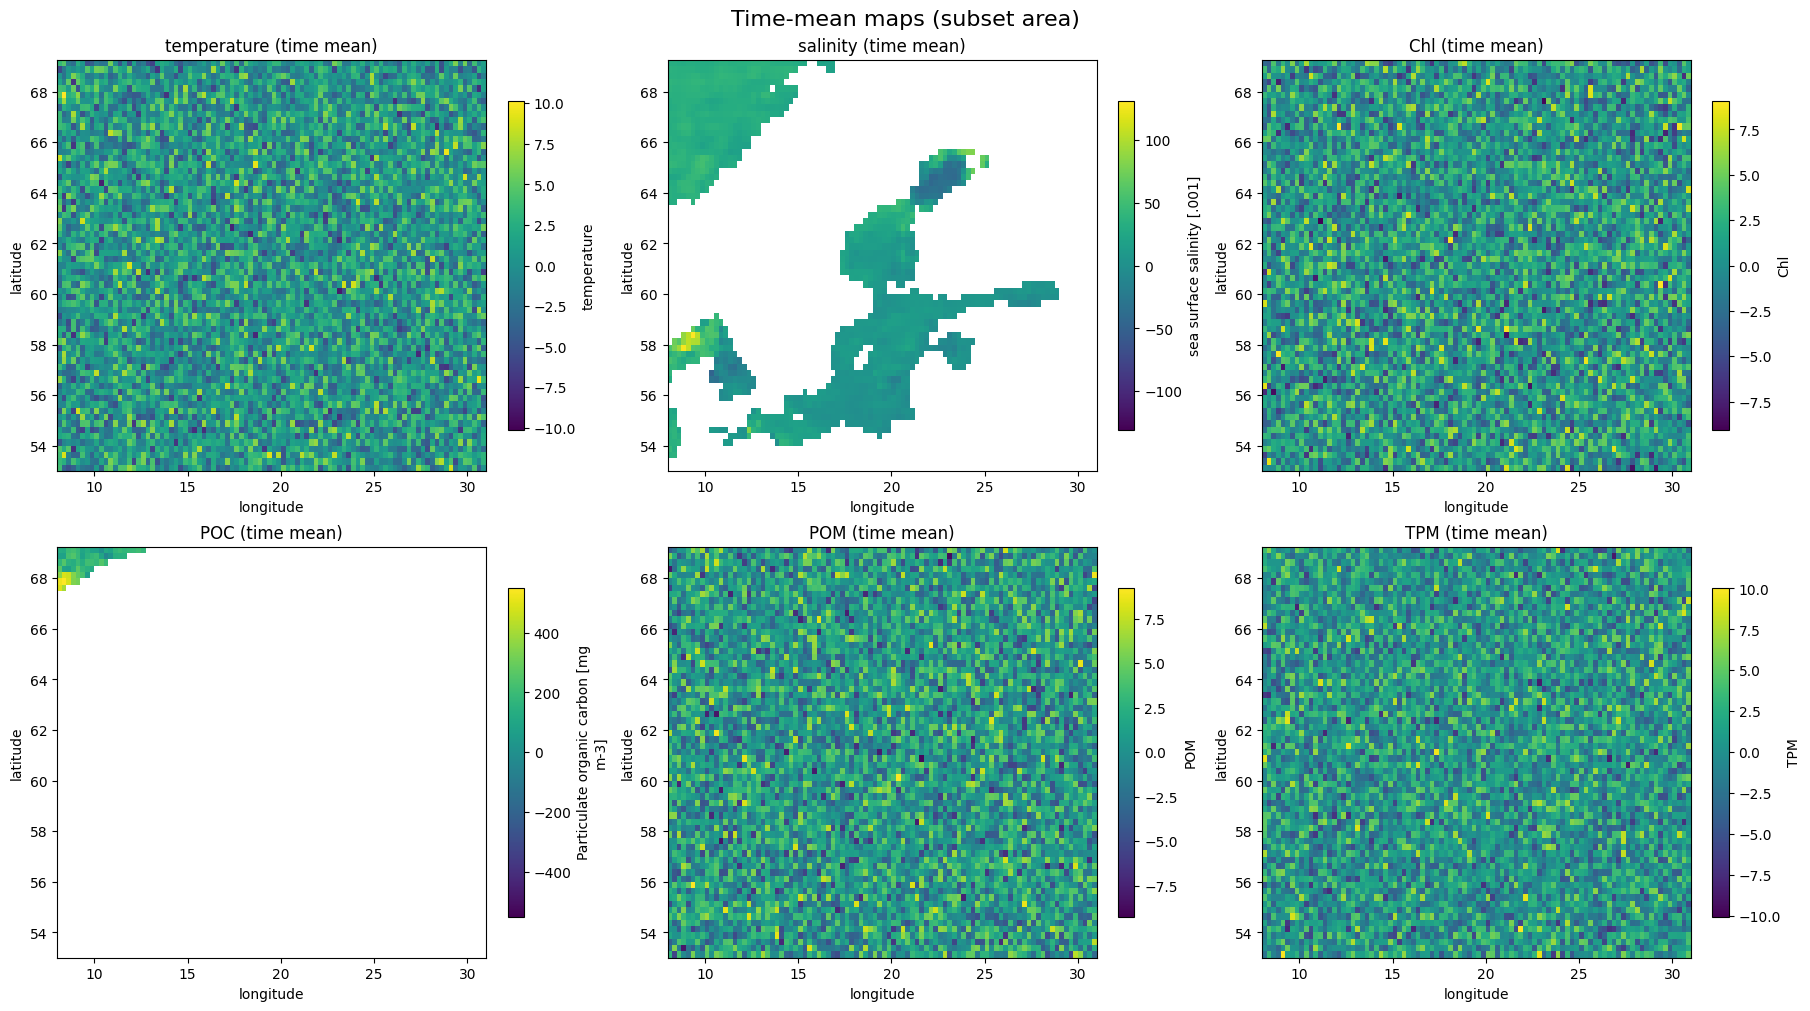

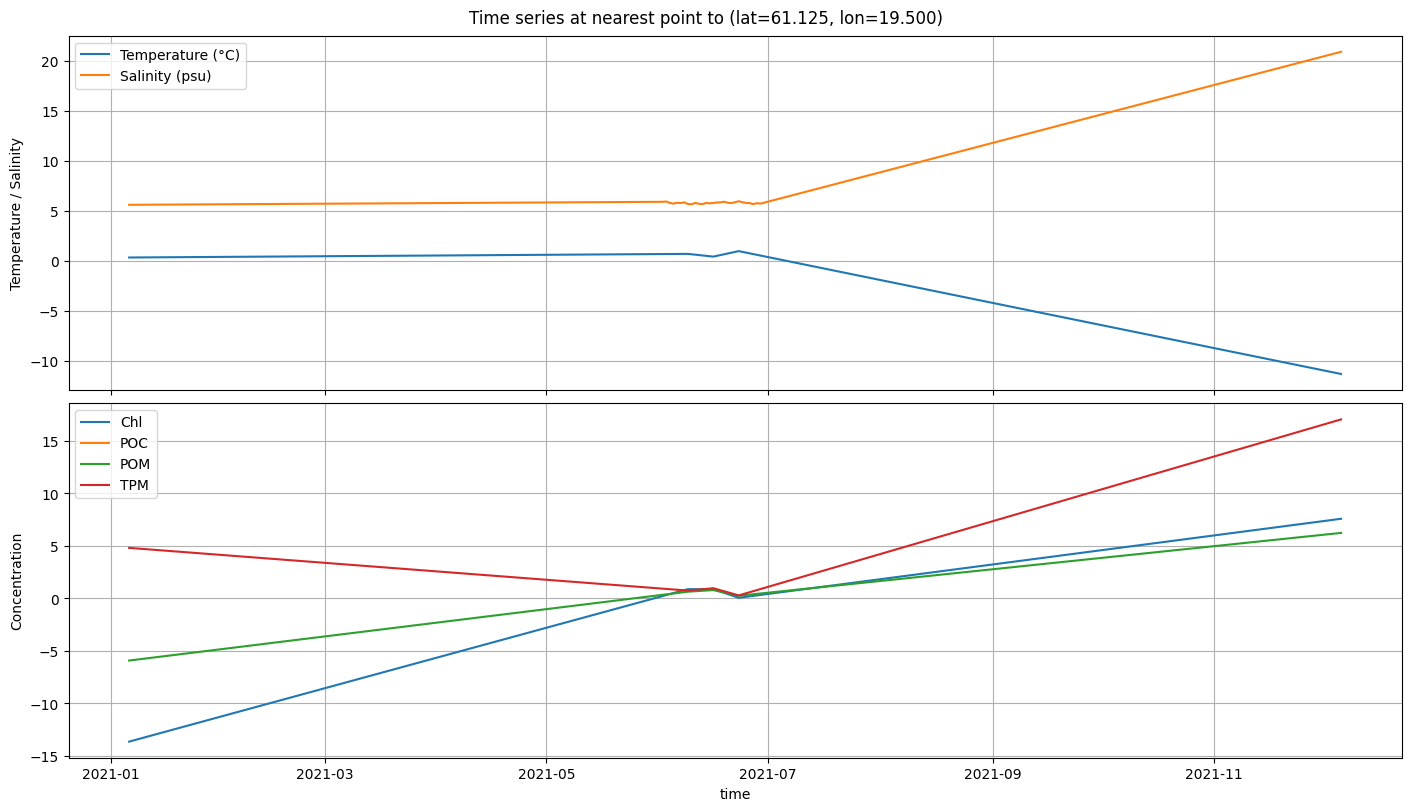

In [11]:
import matplotlib.pyplot as plt

# Quick guard
if ds_daily is None or len(ds_daily.coords.get('time', [])) == 0:
    print("ds_daily is empty or has no time dimension. Skipping plotting.")
else:
    # Plot spatial time-mean maps for key variables
    vars_to_map = ['temperature', 'salinity', 'Chl', 'POC', 'POM', 'TPM']
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
    axes = axes.ravel()

    for ax, var in zip(axes, vars_to_map):
        if var in ds_daily:
            try:
                da_mean = ds_daily[var].mean(dim='time')
                im = da_mean.plot(ax=ax, cmap='viridis', add_colorbar=True, cbar_kwargs={'shrink': 0.8})
                ax.set_title(f"{var} (time mean)")
                ax.set_xlabel("longitude")
                ax.set_ylabel("latitude")
            except Exception as e:
                ax.text(0.5, 0.5, f"Plot failed: {e}", ha='center')
        else:
            ax.text(0.5, 0.5, f"{var} not found", ha='center')

    plt.suptitle("Time-mean maps (subset area)", fontsize=16)
    plt.savefig("ds_daily_time_mean_maps.png", dpi=150)
    plt.show()

    # Time series at a representative point (central pixel)
    lat0 = float(ds_daily.latitude.mean().values)
    lon0 = float(ds_daily.longitude.mean().values)
    point = ds_daily.sel(latitude=lat0, longitude=lon0, method='nearest')

    fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True, constrained_layout=True)

    # Temperature & Salinity
    if 'temperature' in point and 'salinity' in point:
        axs[0].plot(point['time'].values, point['temperature'].values, label='Temperature (°C)')
        axs[0].plot(point['time'].values, point['salinity'].values, label='Salinity (psu)')
        axs[0].set_ylabel("Temperature / Salinity")
        axs[0].legend()
        axs[0].grid(True)
    else:
        axs[0].text(0.5, 0.5, "Temperature or Salinity missing", ha='center')

    # Food-related variables
    food_vars = [v for v in ['Chl', 'POC', 'POM', 'TPM'] if v in point]
    if food_vars:
        for v in food_vars:
            axs[1].plot(point['time'].values, point[v].values, label=v)
        axs[1].set_ylabel("Concentration")
        axs[1].legend()
        axs[1].grid(True)
    else:
        axs[1].text(0.5, 0.5, "No food variables found", ha='center')

    plt.xlabel("time")
    plt.suptitle(f"Time series at nearest point to (lat={lat0:.3f}, lon={lon0:.3f})")
    plt.savefig("ds_daily_point_timeseries.png", dpi=150)
    plt.show()

In [16]:
# subset entire dataset
# 7.910156,53.041213,31.025391,69.364831
# http://bboxfinder.com/#53.041213,7.910156,69.364831,31.025391
bbox = (7.910156, 53.041213, 31.025391, 69.364831)

ds_daily = subset_ds(ds_daily, bbox)
ds_daily

<xarray.Dataset> Size: 96MB
Dimensions:      (time: 335, latitude: 65, longitude: 92)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2021-01-06 2021-01-07 ... 2021-12-06
  * latitude     (latitude) float32 260B 53.12 53.38 53.62 ... 68.62 68.88 69.12
  * longitude    (longitude) float32 368B 8.125 8.375 8.625 ... 30.62 30.88
    depth        float32 4B 0.0
Data variables:
    salinity     (time, latitude, longitude) float64 16MB dask.array<chunksize=(335, 65, 92), meta=np.ndarray>
    POC          (time, latitude, longitude) float64 16MB dask.array<chunksize=(335, 65, 92), meta=np.ndarray>
    temperature  (time, latitude, longitude) float64 16MB dask.array<chunksize=(335, 65, 92), meta=np.ndarray>
    Chl          (time, latitude, longitude) float64 16MB dask.array<chunksize=(335, 65, 92), meta=np.ndarray>
    POM          (time, latitude, longitude) float64 16MB dask.array<chunksize=(335, 65, 92), meta=np.ndarray>
    TPM          (time, latitude, longitude) float64 16MB dask.array<chunksize=(335, 65, 92), meta=np.ndarray>

In [17]:
# Rechunk for optimal performance
# After all the merging and interpolating, Dask's chunks can get fragmented, rechunk so every Dask task receives 
# a data chunk of the exact size

print("Rechunking dataset for optimal performance")
ds_daily = ds_daily.chunk({
    'time': -1,       # Keep all time steps together
    'latitude': 80,   # Process 80 latitudes at once
    'longitude': 110  # Process 110 longitudes at once
})
print("Rechunked dataset")
print(ds_daily.chunks)

Rechunking dataset for optimal performance
Rechunked dataset
Frozen({'time': (335,), 'latitude': (65,), 'longitude': (92,)})


# ShellSIM model wrapper   
takes a 1D numpy array (time-series for one pixel) as input. run entire for loop (time-stepping) and return a 1D numpy array of the result ( eg soft tissue energy time-series). Then Apply in Parallel, using xr.apply_ufunc to apply wrapper function to the gridded data. tell apply_ufunc that the "core dimension" is time, which instructs it to parallelize over all other dimensions (lat, lon)

In [18]:
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_LOG_FILENAME = f"fabm_run_log_{timestamp}.log"

# Define constants for the model output
N_STATES = 11
N_DIAGS = 2
N_OUTPUTS = N_STATES + N_DIAGS

VARIABLE_NAMES = [
    'soft_tissue_energy', 'shell_energy', 'aging', 'C1', 'C2', 'C3', 
    'Chl', 'POC', 'POM', 'TPM', 'O2','TFW', 'SL' 
]

def run_fabm_at_point_full(T_ts, S_ts, Chl_ts, POC_ts, POM_ts, TPM_ts, log_filename):
    """
    Runs FABM time-loop for a single spatial point.
    Returns a 2D array of output (11 states + 2 diagnostics, time).
    """
    # Check for NaN inputs
    if (np.any(np.isnan(T_ts)) or np.any(np.isnan(S_ts)) or 
        np.any(np.isnan(Chl_ts)) or np.any(np.isnan(POC_ts)) or 
        np.any(np.isnan(POM_ts)) or np.any(np.isnan(TPM_ts))):
        return np.full((N_OUTPUTS, time_horizon_len), np.nan)
    
    # Check for non-finite values
    if not (np.all(np.isfinite(T_ts)) and np.all(np.isfinite(S_ts)) and
            np.all(np.isfinite(Chl_ts)) and np.all(np.isfinite(POC_ts)) and
            np.all(np.isfinite(POM_ts)) and np.all(np.isfinite(TPM_ts))):
        return np.full((N_OUTPUTS, time_horizon_len), np.nan)
    
    try:
        # --- START OUTPUT REDIRECTION BLOCK ---
        # with open(os.devnull, 'w') as fnull:
        #     with redirect_stdout(fnull):
        with open(log_filename, 'a') as f_log:
            with redirect_stdout(f_log):
                
                # Initialize model
                model = pyfabm.Model("/home/jovyan/work/ShellSIM_Trials/notebook_timeseries/fabm.yaml")
                
                # Set static dependencies
                model.cell_thickness = 1.0
                model.dependencies["seeding_rate"].value = 0.0
                model.dependencies["harvest_ratio"].value = 0.0
                model.dependencies["current_speed"].value = 1.0
                model.dependencies["air_exposure"].value = 0.0
                model.dependencies["number_of_days_since_start_of_the_year"].value = 0.0
        
        
                # Set INITIAL values for all dependencies
                # We use the first day's value (index 0) to initialize.
                model.dependencies["temperature"].value = float(T_ts[0])
                model.dependencies["practical_salinity"].value = float(S_ts[0])
                model.findStateVariable('Chl1/Chl').value = float(Chl_ts[0])
                model.findStateVariable('POC1/POC').value = float(POC_ts[0])
                model.findStateVariable('POM1/POM').value = float(POM_ts[0])
                model.findStateVariable('TPM1/TPM').value = float(TPM_ts[0])
        
                if not model.start():
                    raise RuntimeError("FABM model failed to start internally.")
        
        
       # Initialize 2D output array (11 states, time)
        outputs = np.zeros((N_OUTPUTS, time_horizon_len))
        
        
        # Daily integration
        for nd in range(time_horizon_len):
            # Set environmental variables
            model.dependencies["temperature"].value = float(T_ts[nd])
            model.dependencies["practical_salinity"].value = float(S_ts[nd])
            
            # Set food variables
            model.findStateVariable('Chl1/Chl').value = float(Chl_ts[nd])
            model.findStateVariable('POC1/POC').value = float(POC_ts[nd])
            model.findStateVariable('POM1/POM').value = float(POM_ts[nd])
            model.findStateVariable('TPM1/TPM').value = float(TPM_ts[nd])
            
            # Calculate and apply growth rates
            state_rates = model.getRates()

            # Perfom forward Euler integration
            model.state[:] += state_rates * 86400.
            
            # Save all 11 states to the first 11 rows
            outputs[:N_STATES, nd] = model.state[:]

            # Save the diagnostics to the next 2 rows
            outputs[N_STATES, nd] = model.diagnostic_variables['Oyster/TFW'].value
            outputs[N_STATES + 1, nd] = model.diagnostic_variables['Oyster/Shell_Length'].value

        # RETURN THE FULL 2D OUTPUT ARRAY (13, time)
        return outputs

    except RuntimeError as e: # Catch the internal failure we raised
        warnings.warn("!!! Model failed to start even after setting initial dependencies.")
        # We can still print the specific FABM error message outside the redirection
        print(f"Model failed to start: {pyfabm.getError()}")
        return np.full((N_OUTPUTS, time_horizon_len), np.nan)
        
    except Exception as e:
        warnings.warn(f"FABM error: {str(e)}")
        return np.full((N_OUTPUTS, time_horizon_len), np.nan)

## Most optimal processing method:  parallelize over the spatial dimensions (latitude, longitude) using xarray.apply_ufunc.  
chunking only the spatial dimensions (latitude and longitude) tells Dask to split the map into tiles, but keep the full time series for each pixel intact.

In [19]:
# apply_ufunc call. It accepts 6 distinct numpy arrays, one for each variable's time series at a single point.
# passes the 6 DataArrays from ds_daily to the 6 arguments of run_fabm_at_point_full
# Apply the model across the grid
# xarray.apply_ufunc: the clean way to run a function over each pixel (lat/lon) in parallel, using Dask underneath
# Dask will distribute this across threads or processes as needed.

print("Setting up parallel computation with apply_ufunc ...")

# result_sten = soft tissue energy 
result_full = xr.apply_ufunc(
    run_fabm_at_point_full,
    
    # input data arrays
    ds_daily['temperature'],   
    ds_daily['salinity'],
    ds_daily['Chl'],
    ds_daily['POC'],
    ds_daily['POM'],
    ds_daily['TPM'],

    # function consumes 6 1D time array
    input_core_dims=[['time']] * 6,
    # outputs a 2D array with 'state' and 'time' dimensions
    output_core_dims=[['state', 'time']],
    
    exclude_dims=set(('time',)),
    # use Dask parallel execution
    dask='parallelized',
    # run over all spatial dimensions
    vectorize=True,
    output_dtypes=[float],
    kwargs={'log_filename': RUN_LOG_FILENAME},
    dask_gufunc_kwargs={
        'allow_rechunk': True,
       'output_sizes': {'state': N_OUTPUTS, 'time': time_horizon_len}
    }
)


# Add time and state coordinates back and set attributes 
result_full = result_full.assign_coords(time=time_horizon)
result_full = result_full.assign_coords(state=VARIABLE_NAMES)

# Convert the DataArray into a Dataset: promotes each 'state' coordinate into a separate DataVariable
result_dataset = result_full.to_dataset(dim='state')

# add attributes to individual variables as requested
result_dataset['soft_tissue_energy'].attrs = {'units': 'J', 'long_name': 'Soft Tissue Energy'}
result_dataset['shell_energy'].attrs = {'units': 'J', 'long_name': 'Shell Energy'}
result_dataset['aging'].attrs = {'units': 'days', 'long_name': 'Aging'}
result_dataset['C1'].attrs = {'units': '', 'long_name': 'C1 State Variable'}
result_dataset['C2'].attrs = {'units': '', 'long_name': 'C2 State Variable'}
result_dataset['C3'].attrs = {'units': '', 'long_name': 'C3 State Variable'}
result_dataset['Chl'].attrs = {'units': 'mg/m3', 'long_name': 'Chlorophyll State'}
result_dataset['POC'].attrs = {'units': 'mg/m3', 'long_name': 'Particulate Organic Carbon State'}
result_dataset['POM'].attrs = {'units': 'mg/m3', 'long_name': 'Particulate Organic Matter State'}
result_dataset['TPM'].attrs = {'units': 'mg/m3', 'long_name': 'Total Particulate Matter State'}
result_dataset['O2'].attrs = {'units': 'mg/L', 'long_name': 'Oxygen State'}
result_dataset['SL'].attrs = {'units': 'cm', 'long_name': 'Shell Length'}
result_dataset['TFW'].attrs = {'units': 'g', 'long_name': 'Total Fresh Weight'}





print("\nTask graph built. Result will be a Dataset with 11 variables.")
print(result_dataset)

Setting up parallel computation with apply_ufunc ...

Task graph built. Result will be a Dataset with 11 variables.
<xarray.Dataset> Size: 208MB
Dimensions:             (latitude: 65, longitude: 92, time: 335)
Coordinates:
  * latitude            (latitude) float32 260B 53.12 53.38 ... 68.88 69.12
  * longitude           (longitude) float32 368B 8.125 8.375 ... 30.62 30.88
  * time                (time) datetime64[ns] 3kB 2021-01-06 ... 2021-12-06
    depth               float32 4B 0.0
Data variables: (12/13)
    soft_tissue_energy  (latitude, longitude, time) float64 16MB dask.array<chunksize=(65, 92, 335), meta=np.ndarray>
    shell_energy        (latitude, longitude, time) float64 16MB dask.array<chunksize=(65, 92, 335), meta=np.ndarray>
    aging               (latitude, longitude, time) float64 16MB dask.array<chunksize=(65, 92, 335), meta=np.ndarray>
    C1                  (latitude, longitude, time) float64 16MB dask.array<chunksize=(65, 92, 335), meta=np.ndarray>
    C2       

# Run computation and Save  
Call .compute() or .to_netcdf() on the result. This triggers Dask to execute the parallel computation and write the final 3D output file.

In [20]:
# Compute with progress bar and save output when done
output_file_name = "direct_gridded_oyster_output_ALL_STATES.nc"

print("Now running dask computation ...")
with ProgressBar():
    result_dataset.to_netcdf(output_file_name, compute=True)

print(f" ****** SUCCESS: Results saved to {output_file_name} ******* ")

Now running dask computation ...
[########################################] | 100% Completed | 2.21 sms
 ****** SUCCESS: Results saved to direct_gridded_oyster_output_ALL_STATES.nc ******* 


In [14]:
# # Clean up
# del ds_poc  
# del ds_sal
# del ds_temp
# del ds_chl
# del ds_pom
# del ds_tpm
# del ds_daily, result_sten
# gc.collect()

# Method 2 on Memory optimization    
Runs in 1:37 ish for start = '02-06-2021' end = '04-06-2021'

In [22]:
time_horizon_len = ds_daily.time.size 
output_file_name = "gridded_oyster_output_ALL_STATES_batched.nc"
N_STATES = 11
STATE_NAMES = ['soft_tissue_energy', 'shell_energy', 'aging', 'C1', 'C2', 'C3', 'Chl_state', 'POC_state', 'POM_state', 'TPM_state', 'O2']


# 2. BATCHING LOOP
# Use  chunk sizes of  data
# Extract chunk definitions from the input data
# This assumes your ds_daily is already chunked (e.g., in Cell 3 of the original notebook)
try:
    lat_chunks = ds_daily.chunks['latitude']
    lon_chunks = ds_daily.chunks['longitude']
except KeyError:
    print("Error: ds_daily must be a Dask-backed xarray object with defined 'latitude' and 'longitude' chunks.")
    # Exit or provide placeholder logic if necessary
    raise

lat_indices = np.cumsum([0] + list(lat_chunks))
lon_indices = np.cumsum([0] + list(lon_chunks))

print(f"Starting batched computation (all 11 states) and saving to {output_file_name}...")

# Loop over Latitude chunks
for i in range(len(lat_chunks)):
    lat_start = lat_indices[i]
    lat_end = lat_indices[i+1]
    
    # Loop over Longitude chunks
    for j in range(len(lon_chunks)):
        lon_start = lon_indices[j]
        lon_end = lon_indices[j+1]

        # Select the spatial subset (chunk) for computation
        ds_subset = ds_daily.isel(
            latitude=slice(lat_start, lat_end),
            longitude=slice(lon_start, lon_end)
        )
        
        print(f"Processing batch: Lat {i+1}/{len(lat_chunks)}, Lon {j+1}/{len(lon_chunks)}")
        
        result_full_batch = xr.apply_ufunc(
            run_fabm_at_point_full,
            
            # input data arrays (subset)
            ds_subset['temperature'],   
            ds_subset['salinity'],
            ds_subset['Chl'],
            ds_subset['POC'],
            ds_subset['POM'],
            ds_subset['TPM'],

            input_core_dims=[['time']] * 6,
            output_core_dims=[['state', 'time']],
            
            exclude_dims=set(('time',)),
            dask='parallelized',
            vectorize=True, 
            output_dtypes=[float],
            kwargs={'log_filename': RUN_LOG_FILENAME},
            dask_gufunc_kwargs={
                'allow_rechunk': True,
                'output_sizes': {'state': N_STATES, 'time': time_horizon_len}
            }
        )
        
        # Add time and state coordinates back
        result_full_batch = result_full_batch.assign_coords(time=ds_subset.time)
        result_full_batch = result_full_batch.assign_coords(state=STATE_NAMES)

        #Convert to Dataset
        result_dataset_batch = result_full_batch.to_dataset(dim='state')
        
        # Add attributes (optional, but good practice)
        result_dataset_batch['soft_tissue_energy'].attrs['units'] = 'J'
        result_dataset_batch['soft_tissue_energy'].attrs['long_name'] = 'Oyster Soft Tissue Energy'
        result_dataset_batch['shell_energy'].attrs['units'] = 'J'
        result_dataset_batch['shell_energy'].attrs['long_name'] = 'Oyster Shell Energy'
        
        # --- Compute and Save (Force memory release for this batch) ---
        with ProgressBar():
            # Use 'w' (write) for the very first chunk (i=0, j=0) to create the file.
            # Use 'a' (append) for all subsequent chunks to add to the existing file.
            mode = 'w' if (i == 0 and j == 0) else 'a'
            
            # Convert to Dataset for cleaner NetCDF output/appending
            result_dataset_batch.to_netcdf(
                output_file_name, 
                mode=mode, 
                format='NETCDF4', 
                compute=True
            )
            
print(f"✅ Success: All spatial batches processed and results saved incrementally to {output_file_name}")

Starting batched computation (all 11 states) and saving to gridded_oyster_output_ALL_STATES_batched.nc...
Processing batch: Lat 1/1, Lon 1/1
[########################################] | 100% Completed | 1.94 sms
✅ Success: All spatial batches processed and results saved incrementally to gridded_oyster_output_ALL_STATES_batched.nc


Plotting time series for point: Lat=67.625, Lon=8.125


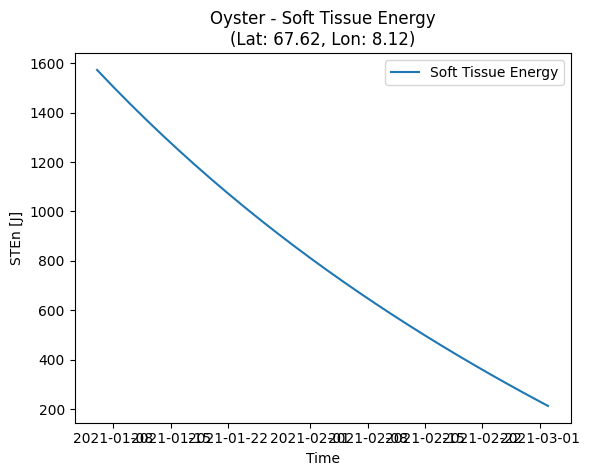

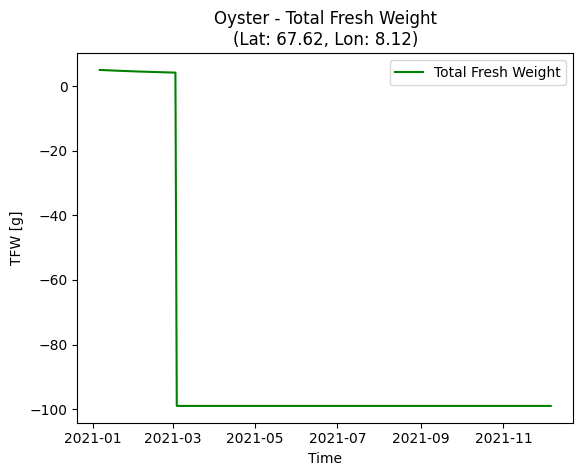

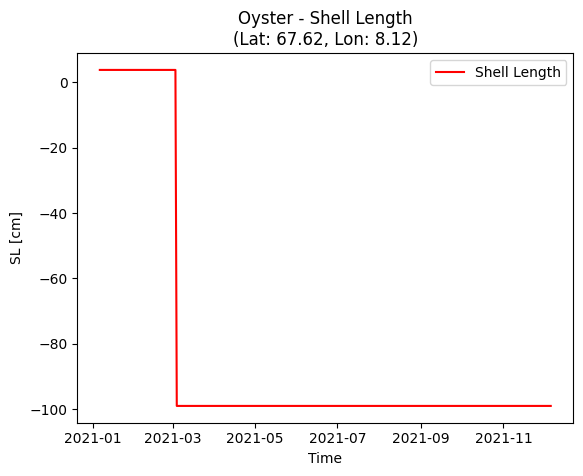

In [23]:


# --- Select a single point to plot ---

plot_lat = 67.625
plot_lon = 8.125

print(f"Plotting time series for point: Lat={plot_lat}, Lon={plot_lon}")

# Use .sel() to extract the time series for this one pixel
# .load() brings the small amount of data into memory for plotting
try:
    single_point_data = result_dataset.sel(
        latitude=plot_lat, 
        longitude=plot_lon, 
        method='nearest'
    ).load()
    
    # Check if the data is valid (not all NaNs)
    if single_point_data.soft_tissue_energy.isnull().all():
        print("Warning: Data at this point is all NaN. Plot will be empty.")
        print("This can happen at pixels over land or where input data was missing.")

    # 2. Create the plots using the selected xarray data
    #    We plot `single_point_data.time` on the x-axis

    # Plot 1: Soft Tissue Energy
    fig1 = plt.figure()
    ax1 = fig1.add_subplot()
    ax1.plot(single_point_data.time, single_point_data.soft_tissue_energy, label='Soft Tissue Energy')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('STEn [J]')
    ax1.set_title(f'Oyster - Soft Tissue Energy\n(Lat: {single_point_data.latitude.item():.2f}, Lon: {single_point_data.longitude.item():.2f})')
    plt.legend()
    plt.show()

    # Plot 2: Total Fresh Weight
    fig2 = plt.figure()
    ax2 = fig2.add_subplot()
    ax2.plot(single_point_data.time, single_point_data.TFW, label='Total Fresh Weight', color='green')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('TFW [g]')
    ax2.set_title(f'Oyster - Total Fresh Weight\n(Lat: {single_point_data.latitude.item():.2f}, Lon: {single_point_data.longitude.item():.2f})')
    plt.legend()
    plt.show()

    # Plot 3: Shell Length
    fig3 = plt.figure()
    ax3 = fig3.add_subplot()
    ax3.plot(single_point_data.time, single_point_data.SL, label='Shell Length', color='red')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('SL [cm]')
    ax3.set_title(f'Oyster - Shell Length\n(Lat: {single_point_data.latitude.item():.2f}, Lon: {single_point_data.longitude.item():.2f})')
    plt.legend()
    plt.show()

except Exception as e:
    print(f"Error: Could not select data for plotting. {e}")
    print("Make sure 'result_dataset' exists and the coordinates are correct.")

In [24]:
import numpy as np

print("Searching for a valid data point...")

# 1. Check for non-NaN values in the TFW variable across all lat/lon/time
#    The .isel() call here extracts the TFW DataArray from the Dataset.
#    .fillna(False) ensures no NaNs in the boolean mask.
valid_mask = ~result_dataset['TFW'].isnull()

# 2. Find the coordinates of the *first* True (non-NaN) value
#    We use np.where to find the indices (index_lat, index_lon, index_time)
#    of the first valid cell.
valid_indices = np.where(valid_mask.values)

if len(valid_indices[0]) == 0:
    print("❌ ERROR: The entire dataset appears to be NaN. Check your input data (ds_daily).")
else:
    # Get the indices of the first valid cell
    first_valid_lat_index = valid_indices[0][0]
    first_valid_lon_index = valid_indices[1][0]

    # Use .isel() to get the actual latitude and longitude values
    valid_lat = result_dataset.latitude.isel(latitude=first_valid_lat_index).item()
    valid_lon = result_dataset.longitude.isel(longitude=first_valid_lon_index).item()

    print(f"✅ Success! Found a valid data point at:")
    print(f"   **Lat: {valid_lat}**")
    print(f"   **Lon: {valid_lon}**")
    
    # --- Update the plotting variables ---
    new_plot_lat = valid_lat
    new_plot_lon = valid_lon
    print("\nUse these new coordinates in your plotting cell.")

Searching for a valid data point...
✅ Success! Found a valid data point at:
   **Lat: 67.625**
   **Lon: 8.125**

Use these new coordinates in your plotting cell.


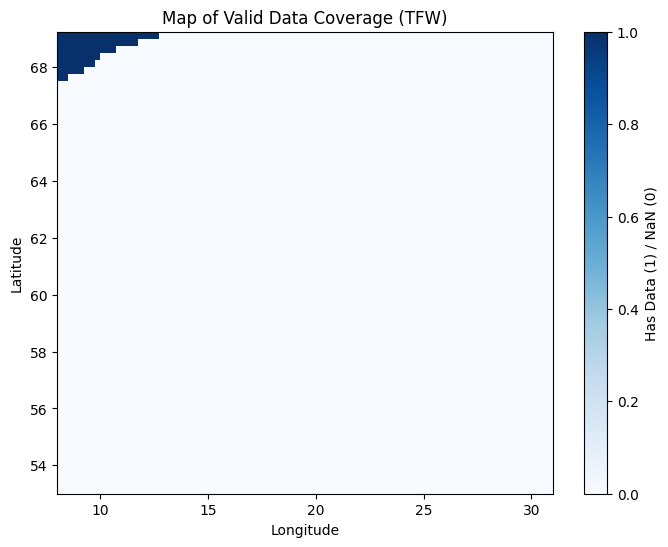


Examine the map above to visually pick a coordinate (blue area) to plot.


In [25]:
# 1. Create a boolean map: True if a pixel has ANY non-NaN data over time
#    .any(dim='time') collapses the time dimension, leaving only (lat, lon)
data_coverage = ~result_dataset['TFW'].isnull().all(dim='time')

# 2. Plot the coverage map
plt.figure(figsize=(8, 6))
# We use .plot() from xarray directly for simplicity
data_coverage.plot(
    cmap='Blues', 
    cbar_kwargs={'label': 'Has Data (1) / NaN (0)'}
)
plt.title('Map of Valid Data Coverage (TFW)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

print("\nExamine the map above to visually pick a coordinate (blue area) to plot.")

## Read and explore produced output

In [26]:
output_file_path="/home/jovyan/work/ShellSIM_Trials/notebook_timeseries/direct_gridded_oyster_output_ALL_STATES.nc"
output_var = 'SL'

ds_output = load_nc_file(output_file_path, output_var)
ds_output

Successfully loaded: SL
🗺️ Geographic Coverage:
  BBOX (xMin, yMin, xMax, yMax)
  BBOX (8.12, 53.12, 30.88, 69.12)
  Lat Range: 53.12° to 69.12° (16.00°)
  Lon Range: 8.12° to 30.88° (22.75°)
  Approximate Area: 2,173,346 km²
---------------------------------------------------



/tmp/ipykernel_3056/2026497504.py:19: FutureWarning: In a future version, xarray will not decode the variable 'aging' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(file_path, chunks=chunking_config)


<xarray.Dataset> Size: 208MB
Dimensions:             (latitude: 65, longitude: 92, time: 335)
Coordinates:
  * latitude            (latitude) float32 260B 53.12 53.38 ... 68.88 69.12
  * longitude           (longitude) float32 368B 8.125 8.375 ... 30.62 30.88
  * time                (time) datetime64[ns] 3kB 2021-01-06 ... 2021-12-06
    depth               float32 4B ...
Data variables: (12/13)
    soft_tissue_energy  (latitude, longitude, time) float64 16MB ...
    shell_energy        (latitude, longitude, time) float64 16MB ...
    aging               (latitude, longitude, time) timedelta64[ns] 16MB ...
    C1                  (latitude, longitude, time) float64 16MB ...
    C2                  (latitude, longitude, time) float64 16MB ...
    C3                  (latitude, longitude, time) float64 16MB ...
    ...                  ...
    POC                 (latitude, longitude, time) float64 16MB ...
    POM                 (latitude, longitude, time) float64 16MB ...
    TPM                 (latitude, longitude, time) float64 16MB ...
    O2                  (latitude, longitude, time) float64 16MB ...
    TFW                 (latitude, longitude, time) float64 16MB ...
    SL                  (latitude, longitude, time) float64 16MB ...